# N2 · 时序连贯度量 (帧间 vs 长程)

> 配套 13.4-L3 · 把「连贯」量化成度量。看两个尺度:
> **帧间跳变** (易, 时空建模能搞定) vs **长程一致** (难, open 问题)。
> 体会 L3 的核心: 连贯是分尺度的, 越长越难。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import video_diffusion as vd
print('就绪')

就绪


## 1. 训练时空 vs 逐帧两个模型 (复用 N1)

In [2]:
torch.manual_seed(0)
data = vd.make_trajectories(n=400, seed=1)
gens = {}
for joint in [True, False]:
    m = vd.build_video_denoiser(joint=joint, seed=0)
    _, sched = vd.train_video(m, data, epochs=500, seed=0)
    gens[joint] = vd.sample_videos(m, sched, n=200, seed=3)
print('生成完毕: 时空', gens[True].shape, '逐帧', gens[False].shape)

生成完毕: 时空 (200, 12, 2) 逐帧 (200, 12, 2)


## 2. 两个尺度的连贯度量
- **帧间跳变** = 相邻帧平均距离 (L1/L2 能搞定的尺度)
- **长程代理** = 首尾段「速度方向」一致性 (L3 难尺度的玩具代理)

In [3]:
def frame_jitter(v):           # 帧间: 相邻帧距离
    return float(np.linalg.norm(v[:,1:]-v[:,:-1], axis=-1).mean())

def longrange_drift(v):        # 长程代理: 整体运动方向的稳定度 (首尾速度方向夹角)
    vel = v[:,1:]-v[:,:-1]                       # (n,T-1,2) 逐帧速度
    early = vel[:,:3].mean(1); late = vel[:,-3:].mean(1)  # 头/尾平均速度
    cos = (early*late).sum(-1) / (np.linalg.norm(early,axis=-1)*np.linalg.norm(late,axis=-1)+1e-8)
    return float(np.clip(cos,-1,1).mean())       # 越接近真实越好

real_j, real_l = frame_jitter(data), longrange_drift(data)
print(f'真实:   帧间跳变 {real_j:.3f}   长程方向一致 {real_l:+.3f}')
for joint in [True, False]:
    tag = '时空' if joint else '逐帧'
    print(f'{tag}: 帧间跳变 {frame_jitter(gens[joint]):.3f}   长程方向一致 {longrange_drift(gens[joint]):+.3f}')

真实:   帧间跳变 0.450   长程方向一致 +0.490
时空: 帧间跳变 0.707   长程方向一致 +0.466
逐帧: 帧间跳变 0.993   长程方向一致 -0.067


## 3. 可视化两个尺度的差距

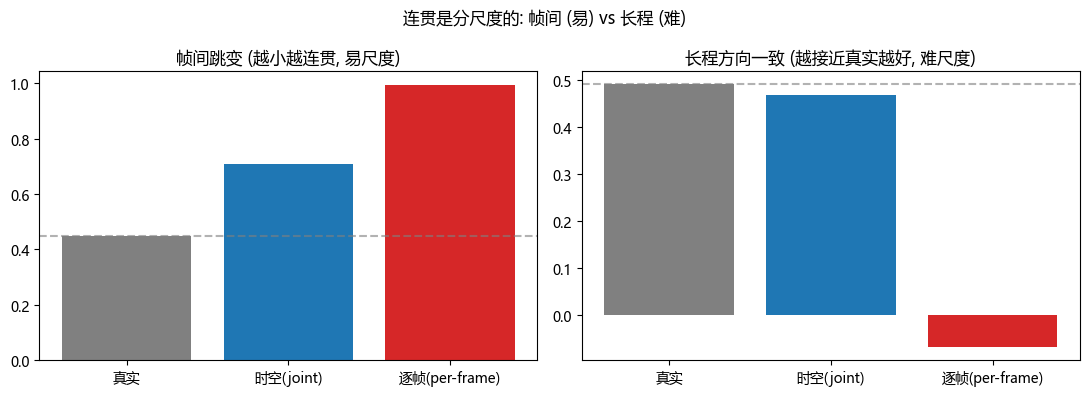

In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
labels = ['真实', '时空(joint)', '逐帧(per-frame)']
jit = [real_j, frame_jitter(gens[True]), frame_jitter(gens[False])]
lr  = [real_l, longrange_drift(gens[True]), longrange_drift(gens[False])]
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].bar(labels, jit, color=['gray','C0','C3']); axes[0].set_title('帧间跳变 (越小越连贯, 易尺度)')
axes[0].axhline(real_j, ls='--', c='gray', alpha=0.6)
axes[1].bar(labels, lr, color=['gray','C0','C3']); axes[1].set_title('长程方向一致 (越接近真实越好, 难尺度)')
axes[1].axhline(real_l, ls='--', c='gray', alpha=0.6)
plt.suptitle('连贯是分尺度的: 帧间 (易) vs 长程 (难)'); plt.tight_layout(); plt.show()

## 4. 反思 (13.4 收口)

你把「连贯」量化成了度量, 并看到它**分尺度**。带走:
- **帧间跳变**: 时空建模就能压到接近真实 (L1/L2 的胜利)。
- **长程一致**: 即使帧间好, 长程方向/物体身份仍可能漂 —— 这是 open 难题 (L3), 接 M13.5 世界模型 (需持久状态记住远处) 和 M11 具身 (物理一致)。
- 评估是瓶颈: 没有好指标抓「物理合理/长程一致」, 还得人/VLM 评 (接 M10.6 + 评估模块)。

> **M13.4 收口**: 视频 = 图扩散 + 时间维; 连贯来自时空联合建模; Sora = 你学过的部件 + 规模; 成本驱动架构。
> **交棒 M13.5「world-models」**: 视频生成再进一步 —— 能预测「动作后世界变成什么」就是世界模型 (可交互视频 + 长程一致 + 接 M11 具身规划)。下一专题 `world-models`。